In [1]:
# load lib
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta
import numpy as np
import vectorbt as vbt
import pandas as pd
import numba as nb
import optuna # Import Optuna

# Add backend directory to path for importing app modules
import sys
from pathlib import Path
backend_path = Path(__file__).parent.parent / "backend" if "__file__" in dir() else Path("../backend").resolve()
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))

from app.services.indicators import avwap_func_nb

In [3]:
## Load datasource from deltalake and save it to local h5 file
REMOTE_HOST = "http://192.168.1.30:9000"

from deltalake import DeltaTable
def load_stock_data() -> pd.DataFrame:
    """Load stock data from delta lake, ensuring index uniqueness to avoid unstack ValueError"""
    try:
        from deltalake import DeltaTable
        storage_options = {
            "AWS_ACCESS_KEY_ID": "CzOwnLkEDXQy951AOqes",
            "AWS_SECRET_ACCESS_KEY": "fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S",
            "AWS_ENDPOINT_URL": REMOTE_HOST,
            "AWS_ALLOW_HTTP": "true",
            "AWS_EC2_METADATA_DISABLED": "true",
            "AWS_REGION": 'us-east-1',
            "aws_conditional_put": "etag",
        }        
        dt = DeltaTable("s3://delta-table-storage/stocks", storage_options=storage_options)

        # Get data for last 2 years
        # Load watchlist symbols from CSV
        watchlist_path = "../backend/models/watchlist.csv"
        watchlist_df = pd.read_csv(watchlist_path)
        watchlist_symbols = watchlist_df.iloc[:, 0].values

        now = pd.Timestamp.now()
        start_date = now - pd.DateOffset(years=10)
        # Load all, then filter
        df = dt.to_pandas(
            filters=[("date", ">=", start_date), ("symbol", "in", watchlist_symbols)], 
            columns=["symbol", "date", "close", "open", "high", "low", "volume"]
        )
        
        # Remove duplicate (date, symbol) rows by keeping the last occurrence
        df = df.drop_duplicates(subset=["date", "symbol"], keep="last")
        # Convert to the same format as H5 store
        df = df.set_index(["date", "symbol"])
        stocks = df.unstack(level=1).bfill().ffill()
        
        print("Successfully loaded data from delta lake")
        return stocks
        
    except Exception as e:
        print(f"Error loading from delta lake: {e}")
        raise

import os
import pandas as pd

local_file = "stocks_data_latest.h5"
store_key = "stocks"

if os.path.exists(local_file):
    print(f"Loading stock data from local HDF5 file: {local_file}")
    with pd.HDFStore(local_file, mode="r") as store:
        df = store[store_key]
else:
    print("Local HDF5 file not found, loading stock data from Delta Lake...")
    df = load_stock_data()
    with pd.HDFStore(local_file, mode="w") as store:
        store.put(store_key, df)
    print(f"Stock data saved to {local_file}")

# Filter df to keep only columns for symbols in the watchlist (once)
watchlist_path = "../backend/models/watchlist.csv"
watchlist_df = pd.read_csv(watchlist_path)
watchlist_symbols = watchlist_df.iloc[:, 0].values
df = df.loc[:, df.columns.get_level_values('symbol').isin(watchlist_symbols)]
df


Local HDF5 file not found, loading stock data from Delta Lake...
Successfully loaded data from delta lake
Stock data saved to stocks_data_latest.h5


close                                                        \
symbol           AAA        ABB        ACB        ACV       ADS        AGG   
date                                                                         
2015-12-28  5.727054   8.201591   3.692765  20.629999  3.940815  15.284813   
2015-12-29  5.828418   8.201591   3.711899  20.629999  3.940815  15.284813   
2015-12-30  6.335237   8.201591   3.731032  20.629999  3.940815  15.284813   
2015-12-31  6.233873   8.201591   3.788433  20.629999  3.940815  15.284813   
2016-01-04  6.385919   8.201591   3.769299  20.629999  3.940815  15.284813   
...              ...        ...        ...        ...       ...        ...   
2025-12-19  8.020000  15.700000  23.900000  51.500000  8.000000  14.400000   
2025-12-22  8.050000  16.000000  24.299999  51.900002  8.010000  14.550000   
2025-12-23  7.970000  15.800000  24.200001  51.599998  8.010000  14.400000   
2025-12-24  7.950000  15.800000  24.299999  50.599998  8.010000  14.400000   
2025-12-25  7.910000  15.700000  24.000000  50.900002  8.000000  14.300000   

                                                       ...       volume  \
symbol            AGR        ANV        APH       ASM  ...      VNINDEX   
date                                                   ...                
2015-12-28   3.110183  17.299999  30.166281  7.303689  ...  100998128.0   
2015-12-29   3.110183  17.299999  30.166281  7.629332  ...   94079184.0   
2015-12-30   3.110183  17.299999  30.166281  7.582811  ...   83672232.0   
2015-12-31   3.110183  17.299999  30.166281  7.675852  ...  102999328.0   
2016-01-04   3.110183  17.299999  30.166281  7.954974  ...   95930576.0   
...               ...        ...        ...       ...  ...          ...   
2025-12-19  16.549999  27.100000   6.420000  6.580000  ...  769377152.0   
2025-12-22  16.700001  27.799999   6.340000  6.620000  ...  755354624.0   
2025-12-23  16.250000  27.299999   6.280000  6.630000  ...  730833984.0   
2025-12-24  16.500000  26.850000   6.350000  6.600000  ...  789923136.0   
2025-12-25  16.350000  26.700001   6.300000  6.580000  ...  803909504.0   

                                                                              \
symbol            VNM       VOS         VPB       VPG        VPI         VRE   
date                                                                           
2015-12-28   821730.0   17090.0  58299312.0    5000.0     5000.0       800.0   
2015-12-29   399590.0    2720.0  58299312.0    5000.0     5000.0       800.0   
2015-12-30   309040.0   23040.0  58299312.0    5000.0     5000.0       800.0   
2015-12-31   688500.0   32170.0  58299312.0    5000.0     5000.0       800.0   
2016-01-04   469320.0   54560.0  58299312.0    5000.0     5000.0       800.0   
...               ...       ...         ...       ...        ...         ...   
2025-12-19  2685700.0  508800.0   9896000.0  381300.0  1472800.0  10546100.0   
2025-12-22  2650700.0  539600.0  13903800.0  143100.0  1730100.0   9656000.0   
2025-12-23  4394700.0  741200.0  12224300.0  150900.0  1795300.0  14877500.0   
2025-12-24  4870200.0  415700.0  15286500.0  242000.0  1499200.0   9103700.0   
2025-12-25  2059600.0  440100.0  14199000.0  238100.0  1714700.0  17089700.0   

                                            
symbol            VSC       VTP        YEG  
date                                        
2015-12-28   213160.0     300.0     6100.0  
2015-12-29    98500.0     300.0     6100.0  
2015-12-30   144540.0     300.0     6100.0  
2015-12-31   284460.0     300.0     6100.0  
2016-01-04   380930.0     300.0     6100.0  
...               ...       ...        ...  
2025-12-19  4302000.0  409800.0  3936500.0  
2025-12-22  5450000.0  267900.0  2657700.0  
2025-12-23  6543700.0  729600.0  3211100.0  
2025-12-24  4043700.0  261500.0  1820700.0  
2025-12-25  6165700.0  335800.0  2096000.0  

[2500 rows x 985 columns]

In [6]:
## Dual RSI strategy
df.close = df.close.round(2)
# Create writable copies of price data to avoid read-only array errors in vectorbt
close = df.close.copy()
high = df.high.copy()
low = df.low.copy()

## RSI from TA-lib
rsi_indicator = vbt.IndicatorFactory.from_talib('RSI')
rsi_df = rsi_indicator.run(df.close, timeperiod=[5, 14])
rsi5 = rsi_df.real.xs(5, level='rsi_timeperiod', axis=1)
rsi14 = rsi_df.real.xs(14, level='rsi_timeperiod', axis=1)

## Donchian Channel (Upper, Lower, Middle)
dc_channel = vbt.IndicatorFactory.from_pandas_ta('donchian', lower_indicators=['lowerband', 'upperband'])
dc_channel = dc_channel.run(high=high, low=low, lower_length=20, upper_length=20)

## AVWAP
vwap_indicator = vbt.IndicatorFactory(
    class_name='AVWAP',
    short_name='avwap',
    input_names=['close', 'high', 'low', 'volume'],
    param_names=['is_highest', 'window'],
    output_names=['avwap']
).from_apply_func(avwap_func_nb)

vwap = vwap_indicator.run(
    df.close, df.high, df.low, df.volume,
    is_highest=[True, False], window=200
).avwap

vwap_highest = vwap.xs(True, level='avwap_is_highest', axis=1)
vwap_lowest = vwap.xs(False, level='avwap_is_highest', axis=1)
# buy signal when rsi14 < 30 and prior 3-day consecutive rsi5 < 30 and rsi5 is decreasing
buy_signal = (
    (rsi14.shift(1) < 30) &
    (rsi5.shift(1).rolling(3).min() < 30) &
    (df.close > df.close.shift(1)) & (rsi5.shift(1) <= rsi5.shift(2)) & (rsi5.shift(2) <= rsi5.shift(3)) &
    # percentage from vwap & close > 10%
    (abs((df.close - vwap_highest.shift(1)) / vwap_highest.shift(1)) > 0.08)
)

sma20 = vbt.MA.run(close, window=20).ma

# sell_signal = df.high.vbt > dc_channel.dcu.shift(1).vbt
# sell_signal = df.high.vbt > sma20.vbt
sell_signal = df.high.vbt > vwap_highest.shift(1).vbt

pf = vbt.Portfolio.from_signals(
    close=df.close, 
    entries=buy_signal, 
    exits=sell_signal, 
    freq='1d', 
    group_by=['symbol'],
    sl_stop=0.05,  # 10% hard stop loss
)
pf.stats(group_by=True)

Start                                2015-12-28 00:00:00
End                                  2025-12-25 00:00:00
Period                                2500 days 00:00:00
Start Value                                      19700.0
End Value                                   52377.341828
Total Return [%]                              165.874832
Benchmark Return [%]                          272.919868
Max Gross Exposure [%]                         77.705128
Total Fees Paid                                      0.0
Max Drawdown [%]                               11.045035
Max Drawdown Duration                   75 days 00:00:00
Total Trades                                        2765
Total Closed Trades                                 2698
Total Open Trades                                     67
Open Trade PnL                                 89.775296
Win Rate [%]                                   54.077094
Best Trade [%]                                 210.26087
Worst Trade [%]                

In [31]:
## Optuna Multi-Objective Optimization for Dual RSI Strategy
## ===========================================================
## Optimizes for: Sharpe Ratio, Total Return, and Sortino Ratio
## Returns Pareto-optimal solutions (best trade-offs between objectives)

def create_multi_objective(df, rsi5, rsi14, vwap_highest, vwap_lowest, dc_channel, close, high, low):
    """Create the Optuna multi-objective function with data closure"""
    
    def objective(trial):
        # ═══════════════════════════════════════════════════════════════════════
        # BUY SIGNAL PARAMETERS
        # ═══════════════════════════════════════════════════════════════════════
        
        # RSI thresholds
        rsi14_threshold = trial.suggest_int("rsi14_threshold", 10, 20, step=1)
        rsi5_threshold = trial.suggest_int("rsi5_threshold", 3, 10, step=1)
        rsi5_rolling_window = trial.suggest_int("rsi5_rolling_window", 2, 5)
        
        # RSI5 decreasing streak (0 = disabled, 1-3 = number of consecutive decreasing days)
        # rsi5_decreasing_days = trial.suggest_int("rsi5_decreasing_days", 0, 3)
        rsi5_decreasing_days = 2
        # Price must be higher than previous close (on/off)
        # require_price_up = trial.suggest_categorical("require_price_up", [True, False])
        
        # VWAP distance threshold (0 = disabled)
        vwap_distance_pct = trial.suggest_float("vwap_distance_pct", 0.0, 0.15, step=0.02)
        
        # ═══════════════════════════════════════════════════════════════════════
        # SELL SIGNAL PARAMETERS
        # ═══════════════════════════════════════════════════════════════════════
        
        exit_type = trial.suggest_categorical("exit_type", ["vwap_highest", "vwap_lowest", "sma", "donchian"])
        sma_period = trial.suggest_int("sma_period", 10, 30, step=5) if exit_type == "sma" else 20
        
        # ═══════════════════════════════════════════════════════════════════════
        # PORTFOLIO PARAMETERS
        # ═══════════════════════════════════════════════════════════════════════
        
        sl_stop = trial.suggest_float("sl_stop", 0.03, 0.12, step=0.01)
        
        # ═══════════════════════════════════════════════════════════════════════
        # BUILD BUY SIGNAL
        # ═══════════════════════════════════════════════════════════════════════
        
        # Start with RSI14 condition (always required)
        buy_signal = (rsi14.shift(1) < rsi14_threshold)
        
        # RSI5 rolling condition
        buy_signal = buy_signal & (rsi5.shift(1).rolling(rsi5_rolling_window).min() < rsi5_threshold)
        
        # Price up condition (optional)
        # if require_price_up:
        buy_signal = buy_signal & (df.close > df.close.shift(1))
        
        # RSI5 decreasing streak (optional)
        if rsi5_decreasing_days >= 1:
            decreasing_cond = rsi5.shift(1) <= rsi5.shift(2)
            if rsi5_decreasing_days >= 2:
                decreasing_cond = decreasing_cond & (rsi5.shift(2) <= rsi5.shift(3))
            if rsi5_decreasing_days >= 3:
                decreasing_cond = decreasing_cond & (rsi5.shift(3) <= rsi5.shift(4))
            buy_signal = buy_signal & decreasing_cond
        
        # VWAP distance condition (optional)
        if vwap_distance_pct > 0:
            vwap_dist = abs((df.close - vwap_highest.shift(1)) / vwap_highest.shift(1))
            buy_signal = buy_signal & (vwap_dist > vwap_distance_pct)
        
        # ═══════════════════════════════════════════════════════════════════════
        # BUILD SELL SIGNAL
        # ═══════════════════════════════════════════════════════════════════════
        
        if exit_type == "vwap_highest":
            sell_signal = df.high.vbt > vwap_highest.shift(1).vbt
        elif exit_type == "vwap_lowest":
            sell_signal = df.high.vbt > vwap_lowest.shift(1).vbt
        elif exit_type == "sma":
            sma = vbt.MA.run(close, window=sma_period).ma
            sell_signal = df.high.vbt > sma.shift(1).vbt
        else:  # donchian
            sell_signal = df.high.vbt > dc_channel.dcu.shift(1).vbt
        
        # ═══════════════════════════════════════════════════════════════════════
        # RUN BACKTEST
        # ═══════════════════════════════════════════════════════════════════════
        
        try:
            pf = vbt.Portfolio.from_signals(
                close=df.close,
                entries=buy_signal,
                exits=sell_signal,
                freq='1d',
                group_by=['symbol'],
                sl_stop=sl_stop,
            )
            
            # Get portfolio-level stats
            stats = pf.stats(group_by=True)
            
            # ═══════════════════════════════════════════════════════════════════════
            # MULTI-OBJECTIVE: Sharpe Ratio, Total Return, Sortino Ratio
            # ═══════════════════════════════════════════════════════════════════════
            
            # Objective 1: Sharpe Ratio
            # sharpe = stats.get('Sharpe Ratio', np.nan)
            # if pd.isna(sharpe) or np.isinf(sharpe):
            #     sharpe = -10.0
            
            # Objective 2: Total Return
            total_return = stats.get('Total Return [%]', 0)
            if pd.isna(total_return) or np.isinf(total_return):
                total_return = -100.0
            
            # Objective 3: Sortino Ratio
            sortino = stats.get('Sortino Ratio', np.nan)
            if pd.isna(sortino) or np.isinf(sortino):
                sortino = -10.0
            
            # Secondary metrics for logging
            win_rate = stats.get('Win Rate [%]', 0)
            max_dd = stats.get('Max Drawdown [%]', 100)
            total_trades = stats.get('Total Trades', 0)
            
            # Penalize if too few trades (not statistically significant)
            trade_penalty = min(1.0, total_trades / 2000) if total_trades < 2000 else 1.0
            # sharpe = sharpe * trade_penalty
            sortino = sortino * trade_penalty
            total_return = total_return * trade_penalty
            
            # Log intermediate results
            trial.set_user_attr("total_return_raw", stats.get('Total Return [%]', 0))
            trial.set_user_attr("win_rate", win_rate)
            trial.set_user_attr("max_drawdown", max_dd)
            trial.set_user_attr("total_trades", total_trades)
            trial.set_user_attr("sharpe_raw", stats.get('Sharpe Ratio', np.nan))
            trial.set_user_attr("sortino_raw", stats.get('Sortino Ratio', np.nan))
            
            # Return tuple of objectives (all maximized)
            return total_return, sortino
            
        except Exception as e:
            print(f"Trial failed: {e}")
            return -100.0, -100.0
    
    return objective

# Create the multi-objective function
objective = create_multi_objective(df, rsi5, rsi14, vwap_highest, vwap_lowest, dc_channel, close, high, low)

# Create multi-objective study
# directions: maximize all three objectives
study = optuna.create_study(
    directions=["maximize", "maximize"],  # Sharpe, Total Return, Sortino
    study_name="dual_rsi_multi_objective",
    sampler=optuna.samplers.NSGAIISampler(seed=42),  # NSGA-II for multi-objective
)

# Run optimization (adjust n_trials as needed)
print("Starting Multi-Objective Optuna optimization...")
print("Objectives: Total Return, Sortino Ratio")
print("=" * 60)
study.optimize(objective, n_trials=1000, show_progress_bar=True)

# Display Pareto-optimal solutions
print("\n" + "=" * 60)
print("MULTI-OBJECTIVE OPTIMIZATION COMPLETE")
print("=" * 60)
print(f"\nFound {len(study.best_trials)} Pareto-optimal solutions")

# Create DataFrame of Pareto-optimal trials
pareto_data = []
for i, trial in enumerate(study.best_trials):
    pareto_data.append({
        'Trial': trial.number,
        # 'Sharpe': trial.values[0],
        'Total Return': trial.values[0],
        'Sortino': trial.values[1],
        'Win Rate': trial.user_attrs.get('win_rate', 0),
        'Max DD': trial.user_attrs.get('max_drawdown', 0),
        'Trades': trial.user_attrs.get('total_trades', 0),
        **trial.params
    })

pareto_df = pd.DataFrame(pareto_data)
print("\nPareto-Optimal Solutions (sorted by Total Return):")
display(pareto_df.sort_values('Total Return', ascending=False).head(10))


[I 2025-12-26 12:32:48,038] A new study created in memory with name: dual_rsi_multi_objective


Starting Multi-Objective Optuna optimization...
Objectives: Total Return, Sortino Ratio


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2025-12-26 12:32:48,580] Trial 0 finished with values: [0.8807711259435604, 0.21673505427171164] and parameters: {'rsi14_threshold': 14, 'rsi5_threshold': 10, 'rsi5_rolling_window': 4, 'vwap_distance_pct': 0.08, 'exit_type': 'donchian', 'sl_stop': 0.09}.
[I 2025-12-26 12:32:48,666] Trial 1 finished with values: [0.4038958913605169, 0.13810878833513096] and parameters: {'rsi14_threshold': 17, 'rsi5_threshold': 3, 'rsi5_rolling_window': 5, 'vwap_distance_pct': 0.12, 'exit_type': 'donchian', 'sl_stop': 0.08}.
[I 2025-12-26 12:32:48,745] Trial 2 finished with values: [0.8287388016091088, 0.21868608499351777] and parameters: {'rsi14_threshold': 14, 'rsi5_threshold': 5, 'rsi5_rolling_window': 4, 'vwap_distance_pct': 0.02, 'exit_type': 'donchian', 'sl_stop': 0.04}.
[I 2025-12-26 12:32:48,831] Trial 3 finished with values: [1.2237025234716121, 0.25586810767075485] and parameters: {'rsi14_threshold': 15, 'rsi5_threshold': 7, 'rsi5_rolling_window': 2, 'vwap_distance_pct': 0.08, 'exit_type': '

,Trial,Total Return,Sortino,Win Rate,Max DD,Trades,rsi14_threshold,rsi5_threshold,rsi5_rolling_window,vwap_distance_pct,exit_type,sl_stop
65,726,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08
108,818,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08
40,669,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08
79,756,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08
163,934,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08
93,790,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08
73,738,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08
188,973,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08
52,703,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08
103,812,23.050433,1.872621,67.526882,3.334399,936,20,10,5,0.0,vwap_highest,0.08


In [30]:
pareto_df

,Trial,Total Return,Sortino,Win Rate,Max DD,Trades,rsi14_threshold,rsi5_threshold,rsi5_rolling_window,rsi5_decreasing_days,vwap_distance_pct,exit_type,sl_stop
0,466,23.464497,2.181070,57.563851,2.551309,1026,20,10,5,0,0.0,vwap_highest,0.04
1,518,24.596969,1.996027,65.266393,3.423165,984,20,10,5,0,0.0,vwap_highest,0.07
2,554,24.596969,1.996027,65.266393,3.423165,984,20,10,5,0,0.0,vwap_highest,0.07
3,562,22.132945,2.190243,53.346266,2.429043,1037,20,10,5,0,0.0,vwap_highest,0.03
4,566,24.596969,1.996027,65.266393,3.423165,984,20,10,5,0,0.0,vwap_highest,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,985,24.680736,1.947945,66.872428,3.652524,980,20,10,5,0,0.0,vwap_highest,0.08
131,994,22.132945,2.190243,53.346266,2.429043,1037,20,10,5,0,0.0,vwap_highest,0.03
132,997,22.132945,2.190243,53.346266,2.429043,1037,20,10,5,0,0.0,vwap_highest,0.03
133,998,22.132945,2.190243,53.346266,2.429043,1037,20,10,5,0,0.0,vwap_highest,0.03


In [23]:
## Visualize Multi-Objective Optuna Results
## ==========================================

import optuna.visualization as vis

# Show Pareto front (2D projections)
print("Pareto Front Visualizations:")
print("=" * 60)

# Sharpe vs Total Return
try:
    fig_pareto_1 = optuna.visualization.plot_pareto_front(
        study, 
        target_names=["Sharpe Ratio", "Total Return", "Sortino Ratio"],
        targets=lambda t: (t.values[0], t.values[1])
    )
    fig_pareto_1.update_layout(title="Pareto Front: Sharpe Ratio vs Total Return")
    fig_pareto_1.show()
except Exception as e:
    print(f"Could not plot Pareto front (Sharpe vs Return): {e}")

# Sharpe vs Sortino
try:
    fig_pareto_2 = optuna.visualization.plot_pareto_front(
        study,
        target_names=["Sharpe Ratio", "Total Return", "Sortino Ratio"],
        targets=lambda t: (t.values[0], t.values[2])
    )
    fig_pareto_2.update_layout(title="Pareto Front: Sharpe Ratio vs Sortino Ratio")
    fig_pareto_2.show()
except Exception as e:
    print(f"Could not plot Pareto front (Sharpe vs Sortino): {e}")

# Show parameter importance for each objective
print("\nParameter Importance by Objective:")
for i, obj_name in enumerate(["Sharpe Ratio", "Total Return", "Sortino Ratio"]):
    try:
        fig_importance = optuna.visualization.plot_param_importances(
            study, 
            target=lambda t: t.values[i],
            target_name=obj_name
        )
        fig_importance.update_layout(title=f"Parameter Importance: {obj_name}")
        fig_importance.show()
    except Exception as e:
        print(f"Could not plot parameter importance for {obj_name}: {e}")

# Show parallel coordinate plot for Pareto-optimal trials
try:
    fig_parallel = optuna.visualization.plot_parallel_coordinate(
        study,
        targets=lambda t: t.values[0]  # Color by Sharpe Ratio
    )
    fig_parallel.update_layout(title="Parallel Coordinates (colored by Sharpe Ratio)")
    fig_parallel.show()
except Exception as e:
    print(f"Could not plot parallel coordinates: {e}")

# Full trials DataFrame
trials_df = study.trials_dataframe()
print("\nAll Trials Summary:")
print(f"Total trials: {len(trials_df)}")
print(f"Pareto-optimal trials: {len(study.best_trials)}")

# Show distribution of objectives
print("\nObjective Distributions:")
# print(f"Sharpe Ratio:  mean={trials_df['values_0'].mean():.3f}, max={trials_df['values_0'].max():.3f}")
print(f"Total Return:  mean={trials_df['values_0'].mean():.2f}%, max={trials_df['values_0'].max():.2f}%")
print(f"Sortino Ratio: mean={trials_df['values_1'].mean():.3f}, max={trials_df['values_1'].max():.3f}")


Pareto Front Visualizations:
Could not plot Pareto front (Sharpe vs Return): The length of `target_names` is supposed to be 2.
Could not plot Pareto front (Sharpe vs Sortino): list index out of range

Parameter Importance by Objective:


Could not plot parameter importance for Sortino Ratio: list index out of range
Could not plot parallel coordinates: plot_parallel_coordinate() got an unexpected keyword argument 'targets'

All Trials Summary:
Total trials: 1000
Pareto-optimal trials: 135

Objective Distributions:
Total Return:  mean=26.77%, max=49.36%
Sortino Ratio: mean=2.562, max=4.252


In [28]:
## Select and Apply Best Parameters from Pareto Front
## =====================================================
## Choose which Pareto-optimal solution to use based on your preference

# Strategy selection options:
# 1. "best_sharpe"  - Highest Sharpe Ratio (risk-adjusted returns)
# 2. "best_return"  - Highest Total Return (aggressive)
# 3. "best_sortino" - Highest Sortino Ratio (downside risk-adjusted)
# 4. "balanced"     - Best combined score (weighted average)

STRATEGY_SELECTION = "balanced"  # Change this to select different strategies

# Find best trial based on selection
if STRATEGY_SELECTION == "best_sharpe":
    best_trial = max(study.best_trials, key=lambda t: t.values[0])
    print("Selected: Best Sharpe Ratio strategy")
elif STRATEGY_SELECTION == "best_return":
    best_trial = max(study.best_trials, key=lambda t: t.values[1])
    print("Selected: Best Total Return strategy")
elif STRATEGY_SELECTION == "best_sortino":
    best_trial = max(study.best_trials, key=lambda t: t.values[2])
    print("Selected: Best Sortino Ratio strategy")
else:  # balanced
    # Normalize and combine objectives (equal weights)
    def combined_score(trial):
        # sharpe_norm = (trial.values[0] + 10) / 20  # Normalize ~[-10, 10] to [0, 1]
        return_norm = (trial.values[0] + 100) / 200  # Normalize ~[-100, 100] to [0, 1]
        sortino_norm = (trial.values[1] + 10) / 20  # Normalize ~[-10, 10] to [0, 1]
        return 0.4 * return_norm + 0.6 * sortino_norm
    best_trial = max(study.best_trials, key=combined_score)
    print("Selected: Balanced strategy (40% Return, 60% Sortino)")

best = best_trial.params

print(f"\nTrial #{best_trial.number}")
print(f"Objectives: Return={best_trial.values[0]:.2f}%, Sortino={best_trial.values[1]:.3f}")
print(f"\nParameters:")
for key, value in best.items():
    print(f"  {key}: {value}")

# Build optimized buy signal
opt_buy_signal = (rsi14.shift(1) < best['rsi14_threshold'])
opt_buy_signal = opt_buy_signal & (rsi5.shift(1).rolling(best['rsi5_rolling_window']).min() < best['rsi5_threshold'])

if best['rsi5_decreasing_days'] >= 1:
    decreasing_cond = rsi5.shift(1) <= rsi5.shift(2)
    if best['rsi5_decreasing_days'] >= 2:
        decreasing_cond = decreasing_cond & (rsi5.shift(2) <= rsi5.shift(3))
    if best['rsi5_decreasing_days'] >= 3:
        decreasing_cond = decreasing_cond & (rsi5.shift(3) <= rsi5.shift(4))
    opt_buy_signal = opt_buy_signal & decreasing_cond

if best['vwap_distance_pct'] > 0:
    vwap_dist = abs((df.close - vwap_highest.shift(1)) / vwap_highest.shift(1))
    opt_buy_signal = opt_buy_signal & (vwap_dist > best['vwap_distance_pct'])

# Build optimized sell signal
if best['exit_type'] == "vwap_highest":
    opt_sell_signal = df.high.vbt > vwap_highest.shift(1).vbt
elif best['exit_type'] == "vwap_lowest":
    opt_sell_signal = df.high.vbt > vwap_lowest.shift(1).vbt
elif best['exit_type'] == "sma":
    opt_sma = vbt.MA.run(close, window=best['sma_period']).ma
    opt_sell_signal = df.high.vbt > opt_sma.shift(1).vbt
else:  # donchian
    opt_sell_signal = df.high.vbt > dc_channel.dcu.shift(1).vbt

# Create optimized portfolio
pf_optimized = vbt.Portfolio.from_signals(
    close=df.close,
    entries=opt_buy_signal,
    exits=opt_sell_signal,
    freq='1d',
    group_by=['symbol'],
    sl_stop=best['sl_stop'],
)

print("\n" + "=" * 60)
print("OPTIMIZED PORTFOLIO STATS")
print("=" * 60)
pf_optimized.stats(group_by=True, metrics=[m for m in pf_optimized.metrics.keys() if m != 'profit_factor'])


Selected: Balanced strategy (40% Return, 60% Sortino)

Trial #566
Objectives: Return=49.01%, Sortino=4.175

Parameters:
  rsi14_threshold: 20
  rsi5_threshold: 10
  rsi5_rolling_window: 5
  rsi5_decreasing_days: 0
  vwap_distance_pct: 0.0
  exit_type: vwap_highest
  sl_stop: 0.06

OPTIMIZED PORTFOLIO STATS


Start                                2015-12-28 00:00:00
End                                  2025-12-25 00:00:00
Period                                2500 days 00:00:00
Start Value                                      19700.0
End Value                                   30703.387656
Total Return [%]                                55.85476
Benchmark Return [%]                          272.919868
Max Gross Exposure [%]                         66.923205
Total Fees Paid                                      0.0
Max Drawdown [%]                                4.545275
Max Drawdown Duration                   93 days 00:00:00
Total Trades                                        1265
Total Closed Trades                                 1252
Total Open Trades                                     13
Open Trade PnL                                 16.041007
Win Rate [%]                                   54.872204
Best Trade [%]                                 195.39749
Worst Trade [%]                

In [ ]:
## Compare Original vs Optimized Strategy
## =======================================

# Per-symbol Sharpe Ratio comparison
original_sharpe = pf.sharpe_ratio()
optimized_sharpe = pf_optimized.sharpe_ratio()

comparison_df = pd.DataFrame({
    'Original Sharpe': original_sharpe,
    'Optimized Sharpe': optimized_sharpe,
    'Improvement': optimized_sharpe - original_sharpe
}).dropna()

print("Per-Symbol Sharpe Ratio Comparison (Top 20 by Improvement):")
display(comparison_df.sort_values('Improvement', ascending=False).head(20))

# Summary statistics
print("\n" + "=" * 60)
print("SUMMARY COMPARISON")
print("=" * 60)
print(f"Average Sharpe (Original):  {original_sharpe.mean():.4f}")
print(f"Average Sharpe (Optimized): {optimized_sharpe.mean():.4f}")
print(f"Improvement: {(optimized_sharpe.mean() - original_sharpe.mean()):.4f}")
print(f"\nSymbols with positive Sharpe (Original):  {(original_sharpe > 0).sum()}")
print(f"Symbols with positive Sharpe (Optimized): {(optimized_sharpe > 0).sum()}")


In [34]:
pf.sharpe_ratio().sort_values(ascending=True)

symbol
KSV      -0.610297
FOX      -0.502406
MCH      -0.423015
STK      -0.412059
KOS      -0.408098
            ...   
PAT            inf
HHS            inf
QTP            inf
DVM            inf
PVI            inf
Name: sharpe_ratio, Length: 197, dtype: float64

In [ ]:
## Example: Using Matrix Series for trading signals

# Buy when: 
#   - up crosses above down (bullish)
#   - OR oversold signal (down < -200) and reversing
ms_buy_signal = (
    (ms['up'] > ms['down']) & (ms['up'].shift(1) <= ms['down'].shift(1))  # up crosses above down
) | (
    ms['oversold_signal'].shift(1) & (ms['up'] > ms['up'].shift(1))  # oversold and turning up
)

# Sell when:
#   - up crosses below down (bearish)  
#   - OR overbought signal (up > 200)
#   - OR CCI breaks below support line
ms_sell_signal = (
    (ms['up'] < ms['down']) & (ms['up'].shift(1) >= ms['down'].shift(1))  # up crosses below down
) | (
    ms['overbought_signal']  # overbought
) | (
    (ms['cci'] < ms['support']) & (ms['cci'].shift(1) >= ms['support'].shift(1))  # CCI breaks support
)

print(f"Buy signals: {ms_buy_signal.sum().sum()}")
print(f"Sell signals: {ms_sell_signal.sum().sum()}")

# You can now use these signals in Portfolio.from_signals:
# pf_ms = vbt.Portfolio.from_signals(
#     close=df.close,
#     entries=ms_buy_signal,
#     exits=ms_sell_signal,
#     freq='1d',
#     group_by=['symbol'],
#     sl_stop=0.05
# )


In [140]:
import numba as nb

@nb.njit(cache=True)
def shannon_entropy_nb(arr, bins=10):
    """
    Numba-optimized Shannon entropy calculation.
    """
    n = len(arr)
    if n < 10:
        return np.nan
    
    # Find min/max for binning
    arr_min = arr[0]
    arr_max = arr[0]
    for i in range(n):
        if arr[i] < arr_min:
            arr_min = arr[i]
        if arr[i] > arr_max:
            arr_max = arr[i]
    
    # Handle edge case where all values are the same
    if arr_max == arr_min:
        return 0.0
    
    # Create histogram manually
    hist = np.zeros(bins, dtype=np.float64)
    bin_width = (arr_max - arr_min) / bins
    
    for i in range(n):
        bin_idx = int((arr[i] - arr_min) / bin_width)
        if bin_idx >= bins:
            bin_idx = bins - 1
        hist[bin_idx] += 1
    
    # Normalize to probabilities
    total = np.sum(hist)
    
    # Calculate entropy
    entropy_val = 0.0
    log2 = np.log(2.0)
    for i in range(bins):
        if hist[i] > 0:
            p = hist[i] / total
            entropy_val -= p * np.log(p) / log2
    
    return entropy_val

@nb.njit(parallel=True, cache=True)
def rolling_entropy_2d(data, window, bins=10):
    """
    Numba-optimized rolling entropy for 2D array (rows=time, cols=symbols).
    Uses parallel processing for speed.
    """
    n_rows, n_cols = data.shape
    result = np.full((n_rows, n_cols), np.nan)
    
    for col in nb.prange(n_cols):
        for row in range(window - 1, n_rows):
            window_data = data[row - window + 1:row + 1, col]
            # Check for NaN in window
            has_nan = False
            for i in range(window):
                if np.isnan(window_data[i]):
                    has_nan = True
                    break
            if not has_nan:
                result[row, col] = shannon_entropy_nb(window_data, bins)
    
    return result

# Calculate daily returns for each symbol
returns = df.close.pct_change()

# Convert to numpy array for numba processing
returns_arr = returns.values.astype(np.float64)

# Calculate rolling entropy using numba (MUCH faster!)
window = 20
bins = 10
entropy_arr = rolling_entropy_2d(returns_arr, window, bins)

# Convert back to DataFrame
entropy_df = pd.DataFrame(entropy_arr, index=returns.index, columns=returns.columns)

# Use a 1-year lookback for the historical average
threshold_window = 252
entropy_ma = entropy_df.rolling(window=threshold_window).mean()
entropy_std = entropy_df.rolling(window=threshold_window).std()
entropy_zscore = ((entropy_df - entropy_ma) / entropy_std).fillna(0)

print(f"Shannon Entropy per symbol (higher = more random):\n")
entropy_zscore.tail(50)


Shannon Entropy per symbol (higher = more random):



symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,BAF,BCG,BCM,BFC,BID,BMP,BSI,BSR,BVB,BVH,BVS,BWE,C4G,CEO,CII,CMG,CNG,CSV,CTD,CTG,CTI,CTR,CTS,DBC,DCM,DDV,DGC,DGW,DHC,DIG,DPG,DPM,DPR,DRC,DRI,DTD,DVM,DXG,DXS,EIB,ELC,EVF,EVG,FCN,FOX,FPT,FRT,FTS,GAS,GEG,GEX,GIL,GKM,GMD,GVR,HAG,HAH,HAX,HBC,HCM,HDB,HDC,HDG,HHS,HHV,HNG,HPG,HPX,HQC,HSG,HTN,HUT,HVN,IDC,IDI,IDJ,IJC,IMP,ITA,KBC,KDC,KDH,KHG,KOS,KSB,KSV,L18,LAS,LCG,LHG,LPB,LSS,MBB,MBS,MCH,MIG,MSB,MSH,MSN,MSR,MWG,NAB,NHA,NHH,NKG,NLG,NT2,NTL,NVL,OCB,OIL,ORS,PAC,PAN,PAT,PC1,PDR,PET,PHR,PLC,PLX,PNJ,POW,PSH,PTB,PVB,PVC,PVD,PVI,PVP,PVS,PVT,QCG,QNS,QTP,REE,SAB,SBT,SCR,SCS,SHB,SHS,SIP,SJS,SKG,SMC,SSB,SSI,STB,STK,SZC,TCB,TCH,TCM,TIG,TNG,TPB,TV2,VC3,VC7,VCB,VCG,VCI,VCS,VDS,VEA,VFS,VGC,VGI,VGS,VGT,VHC,VHM,VIB,VIC,VIX,VJC,VN30,VND,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-10-07,1.263038,1.380771,0.192501,-0.918845,0.646451,-0.806513,-0.867627,0.781682,0.366487,-0.342648,1.063674,-0.173812,0.256862,-0.326760,-0.046077,-0.294057,-0.755839,1.107829,0.434360,1.099013,-1.679368,-1.492143,1.091507,0.964149,0.923295,1.084137,-3.192782,0.616397,-1.284344,1.186505,0.968251,-1.446342,0.252552,1.237708,1.098862,0.066489,1.411887,1.636018,0.513653,-0.265169,-1.224239,2.014730,-2.447641,0.487863,0.531262,-0.472757,-0.060828,0.545876,0.581317,0.212318,-3.405351,0.588106,-0.797302,0.190654,0.528410,2.414790,-0.716780,-1.526770,1.260032,0.365018,0.668858,-0.170424,0.488834,-2.408864,-1.506717,1.688299,0.700091,0.383885,-0.191707,-1.755201,-1.545368,-0.921801,1.220258,1.072456,0.569253,-0.290528,0.289379,0.490288,0.790484,-0.143893,0.114546,0.958581,0.674010,0.135857,-1.503772,0.895574,-1.625885,-0.192860,-0.287381,1.097080,0.225065,1.781745,-0.545752,-2.552364,0.314379,1.218656,1.176933,-0.180148,0.884491,1.793125,0.862268,-1.266830,1.337585,-0.134923,0.156210,1.453150,1.720411,-3.857792,0.374750,0.875930,-0.106320,0.340138,1.523809,0.828199,-0.313197,-0.362168,1.212017,0.555180,0.638919,0.552873,-1.146895,0.055369,1.115679,0.146712,-0.075168,1.351681,0.000639,0.372284,-1.007328,1.529079,-0.867053,1.135902,1.266718,-0.987559,-4.501136,1.091065,1.150924,0.838759,0.952222,-3.502360,0.909482,0.752929,0.298213,0.890073,0.883355,1.122057,0.433257,-1.042362,0.973514,1.635408,1.340198,-0.413885,0.427930,0.562321,-1.119888,1.487115,0.493665,-1.314656,1.119488,0.166174,1.140553,1.580673,0.796544,-2.388437,0.786046,0.531424,-0.055380,1.527975,-0.083046,1.274610,-0.106742,1.440178,-0.550244,1.311652,0.114224,-0.159201,0.660981,1.078836,0.101078,-0.222823,0.077900,-0.430949,1.705197,0.262925,-0.262521,0.467469,-0.874439,-0.548050,-0.599243,-0.148653,1.308429,-1.835380,-0.117518,0.958076,0.542934,0.570060,1.411713,0.365706,0.455987
2025-10-08,1.265786,1.404862,0.381953,-0.980574,0.753323,-1.188284,-1.297000,0.800086,0.368139,-0.476669,1.062533,-0.171408,0.548107,0.123038,0.188602,-0.854456,-1.016607,0.680553,0.644413,0.607545,-1.664001,-1.479169,1.083167,0.967480,0.916054,1.085810,-3.036432,0.702846,-1.322374,1.181922,1.050140,-1.089964,0.165841,1.887791,1.095656,0.070508,1.654696,1.089445,0.743498,-0.261225,-0.360395,1.889075,-2.408727,0.485045,0.678988,-0.294406,-0.057793,0.546388,0.575294,-0.587420,-2.396547,0.777408,-0.944732,0.194049,0.592897,2.228009,-0.893539,-1.310695,1.348962,0.366539,0.664278,-0.602791,0.482839,-2.263765,-0.589734,1.686456,0.486287,0.441094,-0.158669,-1.756812,-0.978234,-1.431149,1.444601,1.093022,0.329689,-0.295315,0.248455,0.493974,1.066848,0.590303,0.113781,0.988435,0.671702,-0.218852,-1.496514,0.723829,-1.609951,-0.193875,-0.284826,0.948772,0.110637,2.037417,-0.267185,-2.520605,0.324633,1.025554,1.156569,-0.236709,1.247283,1.754625,0.859253,-1.256461,1.214795,0.103260,0.155577,1.465648,1.702491,-5.519265,0.373000,1.446389,0.440899,0.339893,1.836304,0.640383,0.059115,-0.481351,1.104090,0.738538,0

<Axes: ylabel='Frequency'>

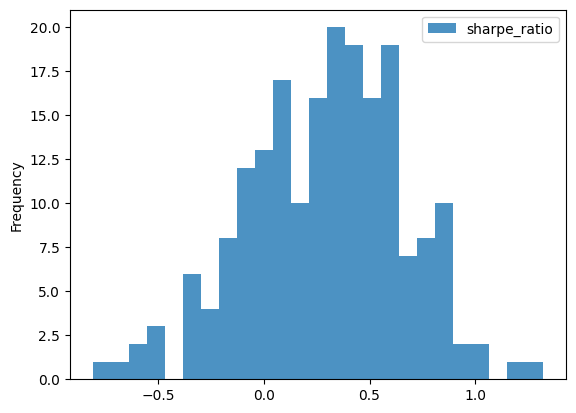

In [136]:
sr = pf.sharpe_ratio().to_frame()
sr = sr.replace([np.inf, -np.inf], np.nan).dropna(subset=['sharpe_ratio'])
sr.sort_values(by='sharpe_ratio', ascending=False).plot.hist(bins=25, alpha=0.8)

In [93]:
# Get list of all metrics and exclude "Profit Factor" to avoid read-only array bug
all_metrics = list(pf.metrics.keys())
metrics_to_use = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
pf_df = pf.stats(metrics=metrics_to_use)
# metrics_to_use
pf_df

Start                                  2015-12-17 00:00:00
End                                    2025-12-15 00:00:00
Period                                  2499 days 00:00:00
Start Value                                          100.0
End Value                                       141.662756
Total Return [%]                                 41.662756
Benchmark Return [%]                            260.780685
Max Gross Exposure [%]                           99.497487
Total Fees Paid                                        0.0
Max Drawdown [%]                                 35.094511
Max Drawdown Duration         1103 days 07:55:07.614213200
Total Trades                                     24.231156
Total Closed Trades                              24.100503
Total Open Trades                                 0.130653
Open Trade PnL                                   -0.093019
Win Rate [%]                                     46.867392
Best Trade [%]                                   30.7495

## Save portfolio of the strategy into file

In [35]:
# ============================================================================
# 1. Get all trades
# ============================================================================
all_trades_df = pf.trades.records_readable.copy()

# Robustly extract symbol: find element matching df.close.columns from Column tuple
close_symbols_set = set(df.close.columns)

def extract_symbol_from_column(col):
    # If tuple, look for entry that matches a symbol name
    if isinstance(col, tuple):
        for v in col:
            if v in close_symbols_set:
                return v
        # fallback: just string representation if not found
        return str(col)
    # If int, treat as index to columns
    elif isinstance(col, int):
        # Defensive: only if within length
        cols = list(df.close.columns)
        return cols[col] if 0 <= col < len(cols) else str(col)
    # If string, check if it's a symbol
    elif isinstance(col, str):
        return col if col in close_symbols_set else str(col)
    else:
        return str(col)

all_trades_df['symbol'] = all_trades_df['Column'].apply(extract_symbol_from_column)

# ============================================================================
# 2. Get stats for all symbols (agg_func=None returns stats per group/symbol)
# ============================================================================
all_metrics = list(pf.metrics.keys())
metrics_to_use = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
# metrics_to_use
all_stats_df = pf.stats(metrics=metrics_to_use, agg_func=None)

# Clean up symbol column (extract from tuple if needed)
all_stats_df = all_stats_df.reset_index().set_index('symbol')

# ============================================================================
# 3. Write to HDF5 file
# ============================================================================
h5_file = "../backend/assets/backtest_results.h5"


# Convert datetime to ISO string format (preserves correctly in HDF5 fixed format)
all_trades_df['Entry Timestamp'] = all_trades_df['Entry Timestamp'].dt.strftime('%Y-%m-%d')
all_trades_df['Exit Timestamp'] = all_trades_df['Exit Timestamp'].dt.strftime('%Y-%m-%d')

# Save trades
all_trades_df.to_hdf(h5_file, key='trades', mode='w')

# Save stats
all_stats_df.to_hdf(h5_file, key='stats', mode='a')

print(f"✓ Saved {len(all_trades_df)} trades to '{h5_file}' (key='trades')")
print(f"✓ Saved stats for {len(all_stats_df)} symbols to '{h5_file}' (key='stats')")

# Show sample
print("\n--- Stats columns available ---")
print(all_stats_df.columns.tolist())
all_trades_df.head()

✓ Saved 2751 trades to '../backend/assets/backtest_results.h5' (key='trades')
✓ Saved stats for 197 symbols to '../backend/assets/backtest_results.h5' (key='stats')

--- Stats columns available ---
['Start', 'End', 'Period', 'Start Value', 'End Value', 'Total Return [%]', 'Benchmark Return [%]', 'Max Gross Exposure [%]', 'Total Fees Paid', 'Max Drawdown [%]', 'Max Drawdown Duration', 'Total Trades', 'Total Closed Trades', 'Total Open Trades', 'Open Trade PnL', 'Win Rate [%]', 'Best Trade [%]', 'Worst Trade [%]', 'Avg Winning Trade [%]', 'Avg Losing Trade [%]', 'Avg Winning Trade Duration', 'Avg Losing Trade Duration', 'Sharpe Ratio', 'Calmar Ratio', 'Omega Ratio', 'Sortino Ratio']


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol
0,0,"(200, AAA)",6.485084,2016-09-15,15.42,0.0,2016-12-09,14.29,0.0,-7.328145,-0.073281,Long,Closed,0,AAA
1,1,"(200, AAA)",7.234337,2016-12-30,12.81,0.0,2017-01-24,11.94,0.0,-6.293873,-0.067916,Long,Closed,1,AAA
2,2,"(200, AAA)",4.907840,2017-11-01,17.60,0.0,2017-11-13,16.24,0.0,-6.674662,-0.077273,Long,Closed,2,AAA
3,3,"(200, AAA)",6.680915,2018-10-12,11.93,0.0,2018-10-25,11.10,0.0,-5.545160,-0.069573,Long,Closed,3,AAA
4,4,"(200, AAA)",6.656926,2018-10-26,11.14,0.0,2018-12-10,12.87,0.0,11.516483,0.155296,Long,Closed,4,AAA


In [86]:
# Read trades
H5_BACKTEST_FILE = "../backend/assets/backtest_results.h5"
all_trades_df = pd.read_hdf(H5_BACKTEST_FILE, key='trades')

# Convert string dates back to datetime if needed
all_trades_df['Entry Timestamp'] = pd.to_datetime(all_trades_df['Entry Timestamp'])
all_trades_df['Exit Timestamp'] = pd.to_datetime(all_trades_df['Exit Timestamp'])
# all_trades_df[all_trades_df['symbol'] == 'AAA']
all_trades_df

,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol
0,0,"(20, 20, AAA)",6.485084,2016-09-15,15.42,0.0,2016-10-12,16.59,0.0,7.587549,0.075875,Long,Closed,0,AAA
1,1,"(20, 20, AAA)",6.905491,2016-11-07,15.58,0.0,2016-11-18,15.79,0.0,1.450153,0.013479,Long,Closed,1,AAA
2,2,"(20, 20, AAA)",8.511921,2016-12-30,12.81,0.0,2017-02-15,14.18,0.0,11.661331,0.106948,Long,Closed,2,AAA
3,3,"(20, 20, AAA)",6.857900,2017-11-01,17.60,0.0,2017-11-28,18.38,0.0,5.349162,0.044318,Long,Closed,3,AAA
4,4,"(20, 20, AAA)",6.975550,2018-01-31,18.07,0.0,2018-04-10,17.26,0.0,-5.650196,-0.044826,Long,Closed,4,AAA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2563,2563,"(20, 20, YEG)",5.890381,2022-04-13,11.90,0.0,2022-06-01,10.49,0.0,-8.305437,-0.118487,Long,Closed,2563,YEG
2564,2564,"(20, 20, YEG)",5.487575,2022-09-12,11.26,0.0,2022-12-05,5.83,0.0,-29.797534,-0.482238,Long,Closed,2564,YEG
2565,2565,"(20, 20, YEG)",4.847358,2023-08-24,6.60,0.0,2023-10-04,7.10,0.0,2.423679,0.075758,Long,Closed,2565,YEG
2566,2566,"(20, 20, YEG)",4.097172,2024-04-09,8.40,0.0,2024-05-10,9.04,0.0,2.622190,0.076190,Long,Closed,2566,YEG


In [ ]:
## Matrix Series Indicator (converted from PineScript)
## Original: http://www.wisestocktrader.com/indicators/2739-flower-indicator

def matrix_series_indicator(high, low, close, 
                             smoother=5, 
                             sup_res_period=50, 
                             sup_res_percentage=100, 
                             price_period=16,
                             overbought=200, 
                             oversold=-200):
    """
    Matrix Series Indicator - converted from PineScript.
    
    Returns:
        dict with keys: 'up', 'down', 'Oo', 'Hh', 'Ll', 'Cc', 
                       'resistance', 'support', 'overbought_signal', 'oversold_signal', 'color'
    """
    nn = smoother
    
    # Weighted close: (high + low + close * 2) / 4
    ys1 = (high + low + close * 2) / 4
    
    # EMA of ys1
    rk3 = ys1.ewm(span=nn, adjust=False).mean()
    
    # Standard deviation of ys1
    rk4 = ys1.rolling(window=nn).std()
    
    # Normalized deviation * 200
    rk5 = (ys1 - rk3) * 200 / rk4
    
    # Triple EMA smoothing
    rk6 = rk5.ewm(span=nn, adjust=False).mean()
    up = rk6.ewm(span=nn, adjust=False).mean()
    down = up.ewm(span=nn, adjust=False).mean()
    
    # Candle OHLC for plotting
    Oo = np.where(up < down, up, down)
    Hh = Oo.copy() if isinstance(Oo, np.ndarray) else Oo
    Ll = np.where(up < down, down, up)
    Cc = Ll.copy() if isinstance(Ll, np.ndarray) else Ll
    
    # Convert to DataFrame if needed
    if isinstance(up, pd.DataFrame):
        Oo = pd.DataFrame(Oo, index=up.index, columns=up.columns)
        Hh = pd.DataFrame(Hh, index=up.index, columns=up.columns)
        Ll = pd.DataFrame(Ll, index=up.index, columns=up.columns)
        Cc = pd.DataFrame(Cc, index=up.index, columns=up.columns)
    
    # Color: red if Oo > Cc, else green if up > down, else red
    color = np.where(Oo > Cc, 'red', np.where(up > down, 'green', 'red'))
    if isinstance(up, pd.DataFrame):
        color = pd.DataFrame(color, index=up.index, columns=up.columns)
    
    # ===== Support/Resistance Zones using CCI =====
    # CCI calculation: (close - SMA(close, n)) / (0.015 * Mean Deviation)
    sma_close = close.rolling(window=price_period).mean()
    mean_dev = close.rolling(window=price_period).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
    cci = (close - sma_close) / (0.015 * mean_dev)
    
    # S/R calculation
    value2 = cci.rolling(window=sup_res_period).max()  # highest
    value3 = cci.rolling(window=sup_res_period).min()  # lowest
    value4 = value2 - value3
    value5 = value4 * (sup_res_percentage / 100)
    resistance_line = value3 + value5
    support_line = value2 - value5
    
    # ===== Overbought/Oversold Signals =====
    # UPshape: when up > overbought
    overbought_signal = (up > overbought)
    # DOWNshape: when down < oversold
    oversold_signal = (down < oversold)
    
    return {
        'up': up,
        'down': down,
        'Oo': Oo,
        'Hh': Hh,
        'Ll': Ll,
        'Cc': Cc,
        'color': color,
        'cci': cci,
        'resistance': resistance_line,
        'support': support_line,
        'overbought_signal': overbought_signal,
        'oversold_signal': oversold_signal,
    }

# Calculate Matrix Series for all symbols
ms = matrix_series_indicator(df.high, df.low, df.close)

print("Matrix Series Indicator calculated!")
print(f"Columns: {list(ms.keys())}")
ms['up'].tail()
